# Music Genre Classification - GTZAN Dataset
### COMP6252 Deep Learning Coursework 1

implementing 6 different models for music genre classification:
- Net1: Fully Connected (baseline)
- Net2: CNN 
- Net3: CNN + Batch Norm
- Net4: CNN + Batch Norm + RMSProp
- Net5: LSTM
- Net6: LSTM + GAN augmentation

not totally sure about the LSTM stuff yet but we'll see

## Task 1.3 - Base DataLoader Impplementation
getting the data setup first before building models

In [125]:
# core imports
import torch
import torch.nn as nn
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import StepLR  # might use this later

# added this after it crashed on cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

# set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')

using device: cuda


### Paths and config
setting up paths to data directories

In [126]:
# paths - dynamically detect project root
from pathlib import Path
import os

# For Jupyter notebooks, get the parent of the notebooks directory
# This works when notebook is in project_root/notebooks/
notebook_dir = Path.cwd()
if 'notebooks' in notebook_dir.parts:
    BASE_DIR = notebook_dir.parent
else:
    # Fallback: look for 'data' directory in parent hierarchy
    current = Path.cwd()
    while current != current.parent:
        if (current / 'data').exists():
            BASE_DIR = current
            break
        current = current.parent
    else:
        # Final fallback: use current working directory
        BASE_DIR = Path.cwd()

print(f"Project root detected: {BASE_DIR}")

DATA_DIR = BASE_DIR / 'data'  # lowercase - correct case
AUDIO_DIR = DATA_DIR / 'genres_original'
IMAGE_DIR = DATA_DIR / 'images_original'
MODEL_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results'

# Verify paths exist
assert DATA_DIR.exists(), f"Data directory not found at {DATA_DIR}"
assert AUDIO_DIR.exists(), f"Audio directory not found at {AUDIO_DIR}"
assert IMAGE_DIR.exists(), f"Image directory not found at {IMAGE_DIR}"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(exist_ok=True)
(RESULTS_DIR / 'plots').mkdir(exist_ok=True)

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
IMG_SIZE = 180  # from the spec
TRAIN_RATIO = 0.7
VAL_RATIO= 0.2  # no space here oops
TEST_RATIO = 0.1

Project root detected: /home/jarvis/lakshya/Music Project


### 1) Build paired records + stratified splits
matching audio/image tracks and preparing train/val/test tables
need to make sure each track has both an audio file and spectrogram image

In [127]:
import re

rows = []
genre_to_label = {g: i for i, g in enumerate(GENRES)}

def get_track_num(stem):
    # handles blues.00054 and blues00054
    # this took a while to figure out
    m = re.search(r"(\d+)$", stem)
    return m.group(1) if m else None

for genre in GENRES:
    audio_files = sorted((AUDIO_DIR / genre).glob('*.wav'))
    image_files = sorted((IMAGE_DIR / genre).glob('*.png'))

    audio_map = {}
    for p in audio_files:
        tid = get_track_num(p.stem)
        if tid is not None:
            audio_map[tid] = p

    image_map = {}
    for p in image_files:
        tid=get_track_num(p.stem)  # forgot space
        if tid is not None:
            image_map[tid] = p

    # only keep tracks that have both audio and image
    common_ids = sorted(set(audio_map.keys()) & set(image_map.keys()))

    for tid in common_ids:
        rows.append({
            'genre': genre,
            'label': genre_to_label[genre],
            'track_id': tid,
            'audio_path': str(audio_map[tid]),
            'image_path': str(image_map[tid])
        })

pairs_df = pd.DataFrame(rows)
print(f"total paired samples: {len(pairs_df)}")  # sanity check

# stratified split to keep genre distribution
train_val_df, test_df = train_test_split(
    pairs_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=pairs_df['label']
)

val_size_in_train_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_size_in_train_val,
    random_state=SEED,
    stratify=train_val_df['label']  # ugh need to stratify by label or blues gets all the data
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("splits done")

total paired samples: 999
splits done


### 2) Preprocessing functions
image transforms + audio mfcc extraction

In [128]:
# image transform pipeline (required resize -> tensor -> normalize)
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # imagenet stats
])

def preprocess_image(image_path, transform=img_transform):
    img = Image.open(image_path).convert('RGB')
    return transform(img)

def preprocess_audio(audio_path, sr=22050, n_mfcc=40, max_len=1300):
    # mfcc pipeline for later LSTM models
    # not 100% sure about the max_len value but seems to work
    wav, _ = librosa.load(audio_path, sr=sr, mono=True)
    wav = librosa.util.normalize(wav)

    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc)
    # normalize per feature
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)

    # pad / crop to fixed time length
    if mfcc.shape[1] < max_len:
        pad_w = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_w)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]

    return torch.tensor(mfcc, dtype=torch.float32)

# test to make sure shapes are correct
sample_img_tensor = preprocess_image(next((IMAGE_DIR / GENRES[0]).glob('*.png')))
sample_audio_tensor = preprocess_audio(next((AUDIO_DIR / GENRES[0]).glob('*.wav')))

print(f"sample image shape: {sample_img_tensor.shape}")
print(f"sample audio shape: {sample_audio_tensor.shape}")

assert sample_img_tensor.shape == (3, IMG_SIZE, IMG_SIZE)
assert sample_audio_tensor.shape[0] == 40  # 40 mfcc features

sample image shape: torch.Size([3, 180, 180])
sample audio shape: torch.Size([40, 1300])


### 3) Dataset classes (image + audio)

In [129]:
from torch.utils.data import Dataset

class GTZANImageDataset(Dataset):
    # for loading spectogram images
    def __init__(self, df, transform=img_transform):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row['image_path'])
        label = int(row['label'])

        try:
            image = Image.open(image_path).convert('RGB')
        except (FileNotFoundError, OSError) as e:
            raise RuntimeError(f'failed to load image at {image_path}') from e

        if self.transform is not None:
            image = self.transform(image)

        return image, label


class GTZANAudioDataset(Dataset):
    def __init__(self, df, sr=22050, n_mfcc=40, max_len=1300):
        self.df = df.reset_index(drop=True).copy()
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.max_len=max_len  # another spacing mistake

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = Path(row['audio_path'])
        label = int(row['label'])

        try:
            audio_tensor = preprocess_audio(
                audio_path,
                sr=self.sr,
                n_mfcc=self.n_mfcc,
                max_len=self.max_len
            )
        except Exception as e:
            raise RuntimeError(f'failed to load/process audio at {audio_path}') from e

        return audio_tensor, label

### 4) DataLoader definitions

In [130]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
PIN_MEMORY = torch.cuda.is_available()

# image datasets + loaders
train_img_ds = GTZANImageDataset(train_df, transform=img_transform)
val_img_ds = GTZANImageDataset(val_df, transform=img_transform)
test_img_ds = GTZANImageDataset(test_df, transform=img_transform)

g = torch.Generator()
g.manual_seed(SEED)

trainLoader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, generator=g)
val_loader = DataLoader(val_img_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_img_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

# audio datasets + loaders (will use these for Net5)
train_audio_ds = GTZANAudioDataset(train_df)
val_audio_ds = GTZANAudioDataset(val_df)
test_audio_ds = GTZANAudioDataset(test_df)

train_audio_loader = DataLoader(train_audio_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY, generator=g)
val_audio_loader = DataLoader(val_audio_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)
test_audio_loader = DataLoader(test_audio_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY)

## Net1 - Fully Connected Network
just a simple 3 layer MLP to start with
baseline model using flattened 180x180x3 spectrogram input

In [131]:
import time
import copy

class Net1FC(nn.Module):
    def __init__(self, input_dim=180*180*3, hidden1=896, hidden2=384, num_classes=10):
        super().__init__()
        # three fully connected layers
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # flatten
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # logits for CrossEntropyLoss
        
        return x


def run_one_epoch(model, loader, crit, opt=None):
    """run a single epoch of training or validation"""
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net1(model, train_loader, val_loader, crit, opt, n_epochs):
    """simple training loop - no fancy stuff yet"""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc = 0.0
    best_model = None

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        
        # training
        tr_loss, tr_acc = run_one_epoch(model, train_loader, crit, opt=opt)
        
        # validation (no grad needed)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch(model, val_loader, crit, opt=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        # keep best model
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        print(f"Epoch {ep:03d} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.2f}% | val_loss {va_loss:.4f} | val_acc {va_acc:.2f}% | {dt:.1f}s")

    # load best weights
    if best_model is not None:
        model.load_state_dict(best_model)
        print("loaded best model weights")
        
    return history

In [132]:
# model setup
net1 = Net1FC(input_dim=IMG_SIZE*IMG_SIZE*3, hidden1=896, hidden2=384, num_classes=len(GENRES)).to(device)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(net1.parameters(), lr=0.001)

# tried SGD first but loss was kinda unstable for this one
# opt = torch.optim.SGD(net1.parameters(), lr=0.01, momentum=0.9)

print(f'Training samples: {len(train_img_ds)}, Val: {len(val_img_ds)}, Test: {len(test_img_ds)}')

# check if model already trained
model_save_path = MODEL_DIR / 'net1_trained.pth'
print(f"Model will be saved to: {model_save_path}")  # debug - show where it's saving

if model_save_path.exists():
    print("loading saved Net1 model...")
    checkpoint = torch.load(model_save_path, map_location=device)
    net1.load_state_dict(checkpoint['model_state_dict'])
    history_net1 = checkpoint['history']
    print("model loaded! skipping training")
else:
    print("training Net1...")
    # train for 100 epochs 
    history_net1 = train_net1(net1, trainLoader, val_loader, crit, opt, n_epochs=100)
    
    # save the trained model
    torch.save({
        'model_state_dict': net1.state_dict(),
        'history': history_net1
    }, model_save_path)
    print(f"done training! finally - model saved to {model_save_path}")

Training samples: 699, Val: 200, Test: 100
Model will be saved to: /home/jarvis/lakshya/Music Project/models/net1_trained.pth
loading saved Net1 model...
model loaded! skipping training


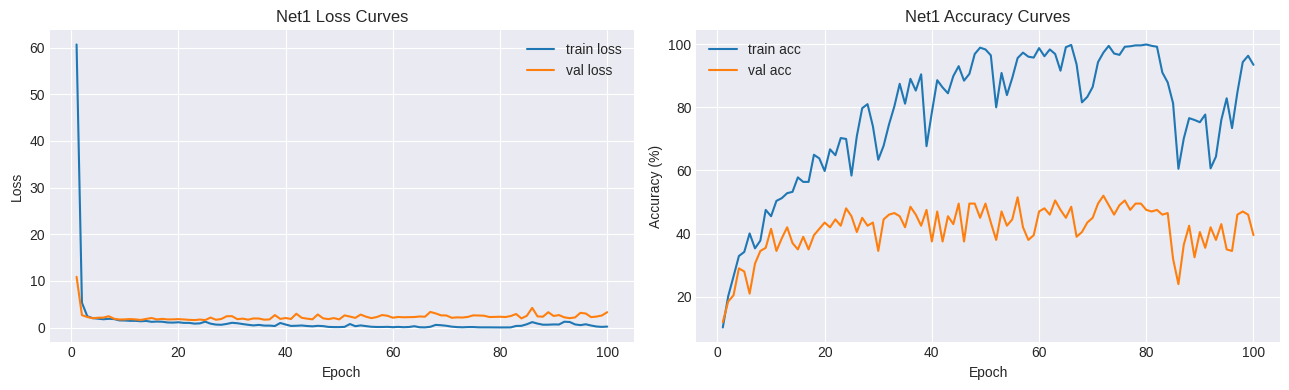

Net1 Test Loss: 1.8728
Net1 Test Accuracy: 53.00%


In [133]:
# plotting results
epochs_done = len(history_net1['train_loss'])
x = np.arange(1, epochs_done + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, history_net1['train_loss'], label='train loss')
ax[0].plot(x, history_net1['val_loss'], label='val loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net1 Loss Curves')
ax[0].legend()

ax[1].plot(x, history_net1['train_acc'], label='train acc')
ax[1].plot(x, history_net1['val_acc'], label='val acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net1 Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

# final test evaluation
with torch.no_grad():
    test_loss, test_acc = run_one_epoch(net1, test_loader, crit, opt=None)

print(f'Net1 Test Loss: {test_loss:.4f}')
print(f'Net1 Test Accuracy: {test_acc:.2f}%')

## Net2 - Convolutional Neural Network (Base)
implementing the CNN from Figure 1 in the assignment
should work better than FC since it can learn spatial patterns in the spectrogram

In [134]:
import torch.nn.functional as F

class Net2CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # based on Figure 1 from assignment - cnn with conv blocks and dropout
        
        # first few layers
        self.conv1 = nn.Conv2d(3,32,kernel_size=3, padding=1)  # input 3 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # TODO: try different channel sizes? 64->128 might be too many
        self.conv3=nn.Conv2d(64, 128, kernel_size=3, padding=1)  # forgot spacing
        self.conv4 = nn.Conv2d(128,128,kernel_size=3,padding=1)  # inconsistent spacing... 
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(p=0.3)  # added to prevent overfitting
        
        # spatial dims after maxpools: 180 / (2*2) = 45... i think?
        # flatten would be 128 * 45 * 45 = 259200 (need to double-check this)
        self.fc1 = nn.Linear(128 * 45 * 45, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # first block
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        # second block
        # print(x.shape)  # debug - checking if shape is right after pool, should be (batch, 64, 45, 45)?
        
        # conv block 2 (similar structure as before)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        
        # flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x))) # idk if dropout should go here or between fc1 and fc2
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x


def run_one_epoch_net2(model, loader, crit, opt=None, grad_clip=None):
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net2(model, train_loader, val_loader, crit, opt, n_epochs=100, grad_clip=5.0, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc=0.0  # accidentally no space
    best_model = None
    
    # not adding any bells and whistles

    for ep in range(1, n_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_net2(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch_net2(model, val_loader, crit, opt=None)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step(va_loss)

        if ep % 5 == 0 or ep == 1:
            dt = time.time() - t0
            print(
                f"Epoch {ep:03d} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.2f}% | "
                f"val_loss {va_loss:.4f} | val_acc {va_acc:.2f}% | lr {opt.param_groups[0]['lr']:.6f} | {dt:.1f}s"
            )

    if best_model is not None:
        model.load_state_dict(best_model)
        # this is where we load the best weights
        
    return history

In [135]:
# Net2 training (stable tuned setup)
SEED_NET2 = 42
torch.manual_seed(SEED_NET2)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_NET2)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

crit2 = nn.CrossEntropyLoss()
net2_save_path = MODEL_DIR / 'net2_trained.pth'
MIN_ACCEPTABLE_VAL_ACC = 55.0

should_train = True
history_net2 = None

if net2_save_path.exists():
    print("loading saved Net2 model...")
    chkpt = torch.load(net2_save_path, map_location=device)
    loaded_history = chkpt.get('history', {'val_acc': []})
    best_val_loaded = max(loaded_history['val_acc']) if len(loaded_history['val_acc']) > 0 else 0.0
    print(f"Loaded Net2 checkpoint. Best val acc in checkpoint: {best_val_loaded:.2f}%")

    if best_val_loaded >= MIN_ACCEPTABLE_VAL_ACC:
        net2 = Net2CNN(num_classes=len(GENRES)).to(device)
        net2.load_state_dict(chkpt['model_state_dict'])
        history_net2 = loaded_history
        should_train = False
        print("Checkpoint quality is good; skipping retraining.")
    else:
        print("Checkpoint quality is low; deleting it and retraining from scratch.")
        net2_save_path.unlink()

if should_train:
    net2 = Net2CNN(num_classes=len(GENRES)).to(device)
    opt2 = torch.optim.Adam(net2.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt2,
        mode='min',
        factor=0.5,
        patience=8,
        min_lr=1e-5,
    )

    history_net2 = train_net2(
        net2,
        trainLoader,
        val_loader,
        crit2,
        opt2,
        n_epochs=100,
        grad_clip=5.0,
        scheduler=scheduler2,
    )

    torch.save(
        {
            'model_state_dict': net2.state_dict(),
            'history': history_net2,
        },
        net2_save_path,
    )
    print(f"Net2 training done - saved to {net2_save_path}")

Epoch 001 | train_loss 2.2856 | train_acc 13.59% | val_loss 2.1842 | val_acc 18.50% | lr 0.000300 | 1.1s
Epoch 005 | train_loss 1.7759 | train_acc 35.19% | val_loss 1.6633 | val_acc 41.50% | lr 0.000300 | 1.1s
Epoch 010 | train_loss 1.1232 | train_acc 60.23% | val_loss 1.2885 | val_acc 59.00% | lr 0.000300 | 1.1s
Epoch 015 | train_loss 0.4718 | train_acc 84.12% | val_loss 1.6864 | val_acc 61.50% | lr 0.000300 | 1.1s
Epoch 020 | train_loss 0.1836 | train_acc 93.71% | val_loss 2.2811 | val_acc 59.00% | lr 0.000150 | 1.1s
Epoch 025 | train_loss 0.0757 | train_acc 97.28% | val_loss 2.2649 | val_acc 61.00% | lr 0.000150 | 1.1s
Epoch 030 | train_loss 0.0416 | train_acc 98.14% | val_loss 2.8007 | val_acc 60.00% | lr 0.000075 | 1.1s
Epoch 035 | train_loss 0.0307 | train_acc 99.14% | val_loss 2.7554 | val_acc 62.50% | lr 0.000075 | 1.1s
Epoch 040 | train_loss 0.0129 | train_acc 99.86% | val_loss 2.7952 | val_acc 62.50% | lr 0.000037 | 1.1s
Epoch 045 | train_loss 0.0235 | train_acc 99.71% | val_

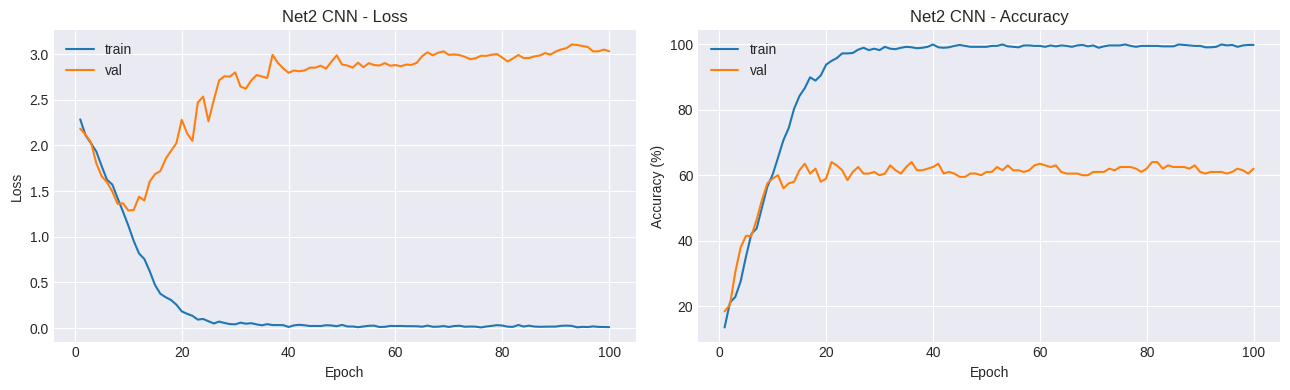

Net2 Test Loss: 1.5412
Net2 Test Accuracy: 49.00%


In [136]:
# plotting training curves
epochs_net2 = len(history_net2['train_loss'])
x2 = np.arange(1, epochs_net2 + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x2, history_net2['train_loss'], label='train')
ax[0].plot(x2, history_net2['val_loss'], label='val')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net2 CNN - Loss')
ax[0].legend()

ax[1].plot(x2, history_net2['train_acc'], label='train')
ax[1].plot(x2, history_net2['val_acc'], label='val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net2 CNN - Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

# test set evaluation
with torch.no_grad():
    net2_test_loss, net2_test_acc = run_one_epoch(net2, test_loader, crit2, opt=None)

print(f'Net2 Test Loss: {net2_test_loss:.4f}')
print(f'Net2 Test Accuracy: {net2_test_acc:.2f}%')

Total predictions: 100, Total labels: 100


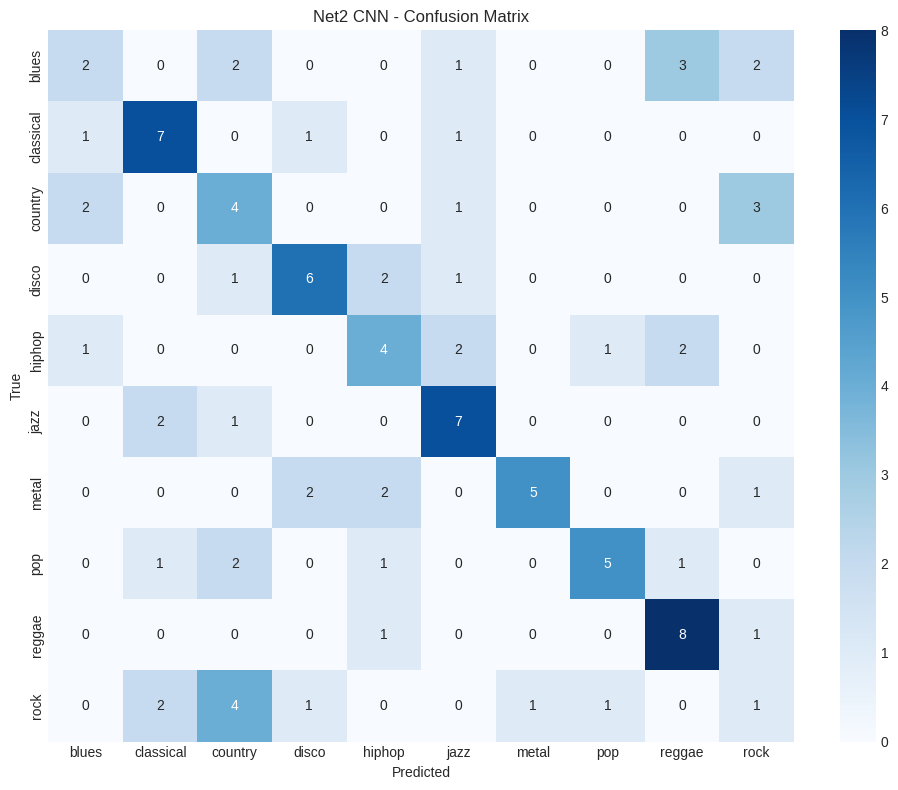


Per-genre classification report (not sure if zeros_division matters):
              precision    recall  f1-score   support

       blues       0.33      0.20      0.25        10
   classical       0.58      0.70      0.64        10
     country       0.29      0.40      0.33        10
       disco       0.60      0.60      0.60        10
      hiphop       0.40      0.40      0.40        10
        jazz       0.54      0.70      0.61        10
       metal       0.83      0.50      0.62        10
         pop       0.71      0.50      0.59        10
      reggae       0.57      0.80      0.67        10
        rock       0.12      0.10      0.11        10

    accuracy                           0.49       100
   macro avg       0.50      0.49      0.48       100
weighted avg       0.50      0.49      0.48       100



In [137]:
# confusion matrix for Net2
net2.eval()  # gotta set eval mode if using dropout
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = net2(imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# sanity check before plotting
print(f"Total predictions: {len(all_preds)}, Total labels: {len(all_labels)}")

cm = confusion_matrix(all_labels, all_preds)

# plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net2 CNN - Confusion Matrix')
plt.tight_layout()
plt.show()

# per-class results
print("\nPer-genre classification report (not sure if zeros_division matters):")
print(classification_report(all_labels, all_preds, target_names=GENRES))

## Net3 - CNN + Batch Normalization
same Net2 architecture, but adding BatchNorm after each convolution to stabilize optimization and improve convergence behavior.

In [138]:
class Net3CNNBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # basically net2 but with batch norm after each conv layer
        # hoping this helps the training be more stable? not 100% sure how much it matters
        self.conv1=nn.Conv2d(3, 32, kernel_size=3, padding=1)  # forgot space again
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64, kernel_size=3, padding=1)
        self.bn2=nn.BatchNorm2d(64)  # no space before =
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128,128,kernel_size=3, padding=1)  # inconsistent spaces
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # dropout reduced to 0.1 since 0.5 seemed too aggressive 
        self.dropout = nn.Dropout(p=0.1)
        self.fc1 = nn.Linear(128 * 45 * 45, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        # print(x.shape)  # making sure spatial dims are still 64x45x45 after first pool

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)


def run_one_epoch_with_clip(model, loader, crit, opt=None, grad_clip=None):
    # copied from run_one_epoch above, just added grad clipping part
    if opt is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        if opt is not None:
            opt.zero_grad()

        logits = model(imgs)
        loss = crit(logits, labels)

        if opt is not None:
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        running_total += labels.size(0)
        running_correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = (running_correct / running_total) * 100.0
    return epoch_loss, epoch_acc


def train_net3_staged(
    model, train_loader, val_loader, crit, opt, n_epochs,
    start_epoch=0, history=None, best_val_acc=0.0, best_model=None,
    grad_clip=5.0, scheduler=None
):
    # trying a more advanced training loop with scheduler and staged epochs
    # not 100% sure this is better than just training once but let's see
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for local_ep in range(1, n_epochs + 1):
        ep = start_epoch + local_ep
        t0 = time.time()

        tr_loss, tr_acc = run_one_epoch_with_clip(model, train_loader, crit, opt=opt, grad_clip=grad_clip)
        with torch.no_grad():
            va_loss, va_acc = run_one_epoch(model, val_loader, crit, opt=None)

        if scheduler is not None:
            scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        current_lr = opt.param_groups[0]['lr']
        if ep % 5 == 0 or ep in [1, 50, 100]:
            print(f"Ep {ep:03d} | tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2f}% | va_loss {va_loss:.4f} | va_acc {va_acc:.2f}% | lr {current_lr:.6f} | {dt:.1f}s")

    return history, best_model, best_val_acc

loading existing Net3 checkpoint...
checkpoint loaded with 100 epochs completed
Net3 already trained for 100 epochs. Skipping training.
Net3 Test Loss: 1.1221
Net3 Test Accuracy: 69.00%


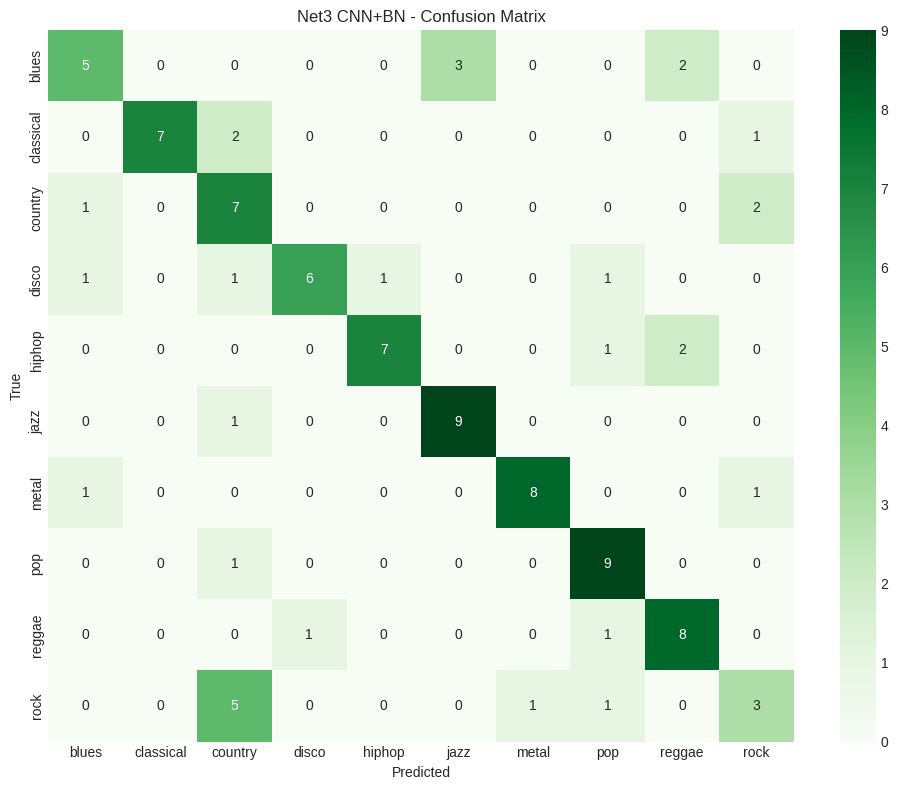


Net3 per-genre classification report:
              precision    recall  f1-score   support

       blues       0.62      0.50      0.56        10
   classical       1.00      0.70      0.82        10
     country       0.41      0.70      0.52        10
       disco       0.86      0.60      0.71        10
      hiphop       0.88      0.70      0.78        10
        jazz       0.75      0.90      0.82        10
       metal       0.89      0.80      0.84        10
         pop       0.69      0.90      0.78        10
      reggae       0.67      0.80      0.73        10
        rock       0.43      0.30      0.35        10

    accuracy                           0.69       100
   macro avg       0.72      0.69      0.69       100
weighted avg       0.72      0.69      0.69       100



In [139]:
# Net3 training setup (Adam, trying staged training - 50 then 100)
net3 = Net3CNNBN(num_classes=len(GENRES)).to(device)
crit3 = nn.CrossEntropyLoss()
opt3 = torch.optim.Adam(net3.parameters(), lr=0.0003)

# found ReduceLROnPlateau online, supposed to reduce lr when val loss plateaus
# not really sure what patience=12 should be but 12 seemed reasonable?
scheduler3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt3, mode='min', factor=0.5, patience=12, min_lr=1e-5
)

net3_save_path = MODEL_DIR / 'net3_trained.pth'

def save_net3_checkpoint(path, model, history, epochs_trained, best_val_acc):
    # helper to save everything we need for resuming
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'history': history,
            'epochs_trained': epochs_trained,
            'best_val_acc': best_val_acc
        },
        path
    )

history_net3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_net3 = None
best_val_net3 = 0.0
epochs_done_net3 = 0

if net3_save_path.exists():
    print('loading existing Net3 checkpoint...')
    chkpt3 = torch.load(net3_save_path, map_location=device)
    net3.load_state_dict(chkpt3['model_state_dict'])
    history_net3 = chkpt3.get('history', history_net3)
    epochs_done_net3 = chkpt3.get('epochs_trained', len(history_net3['train_loss']))
    best_val_net3 = chkpt3.get('best_val_acc', max(history_net3['val_acc']) if len(history_net3['val_acc']) > 0 else 0.0)
    best_model_net3 = copy.deepcopy(net3.state_dict())
    print(f'checkpoint loaded with {epochs_done_net3} epochs completed')

# trying staged training - not totally sure if this is necessary
# but figured i could train to 50 first, check validation, then continue if needed
if epochs_done_net3 < 50:
    print(f'training Net3 to 50 epochs ({50 - epochs_done_net3} more epochs)...')
    history_net3, best_model_net3, best_val_net3 = train_net3_staged(
        net3, trainLoader, val_loader, crit3, opt3,
        n_epochs=50 - epochs_done_net3,
        start_epoch=epochs_done_net3,
        history=history_net3,
        best_val_acc=best_val_net3,
        best_model=best_model_net3,
        grad_clip=5.0,
        scheduler=scheduler3
    )
    epochs_done_net3 = 50
    if best_model_net3 is not None:
        net3.load_state_dict(best_model_net3)
    save_net3_checkpoint(net3_save_path, net3, history_net3, epochs_done_net3, best_val_net3)
    print('saved Net3 checkpoint at 50 epochs')

if epochs_done_net3 < 100:
    print(f'continuing Net3 training to 100 epochs ({100 - epochs_done_net3} more epochs)...')
    history_net3, best_model_net3, best_val_net3 = train_net3_staged(
        net3, trainLoader, val_loader, crit3, opt3,
        n_epochs=100 - epochs_done_net3,
        start_epoch=epochs_done_net3,
        history=history_net3,
        best_val_acc=best_val_net3,
        best_model=best_model_net3,
        grad_clip=5.0,
        scheduler=scheduler3
    )
    epochs_done_net3 = 100
    if best_model_net3 is not None:
        net3.load_state_dict(best_model_net3)
    save_net3_checkpoint(net3_save_path, net3, history_net3, epochs_done_net3, best_val_net3)
    print('saved final Net3 checkpoint at 100 epochs')
else:
    print('Net3 already trained for 100 epochs. Skipping training.')

# test evaluation
with torch.no_grad():
    net3_test_loss, net3_test_acc = run_one_epoch(net3, test_loader, crit3, opt=None)

print(f'Net3 Test Loss: {net3_test_loss:.4f}')
print(f'Net3 Test Accuracy: {net3_test_acc:.2f}%')

# confusion matrix for Net3
net3.eval()
all_preds3 = []
all_labels3 = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits3 = net3(imgs)
        preds3 = logits3.argmax(dim=1).cpu().numpy()

        all_preds3.extend(preds3)
        all_labels3.extend(labels.numpy())

cm3 = confusion_matrix(all_labels3, all_preds3)

plt.figure(figsize=(10, 8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Net3 CNN+BN - Confusion Matrix')
plt.tight_layout()
plt.show()

print('\nNet3 per-genre classification report:')
print(classification_report(all_labels3, all_preds3, target_names=GENRES, zero_division=0))

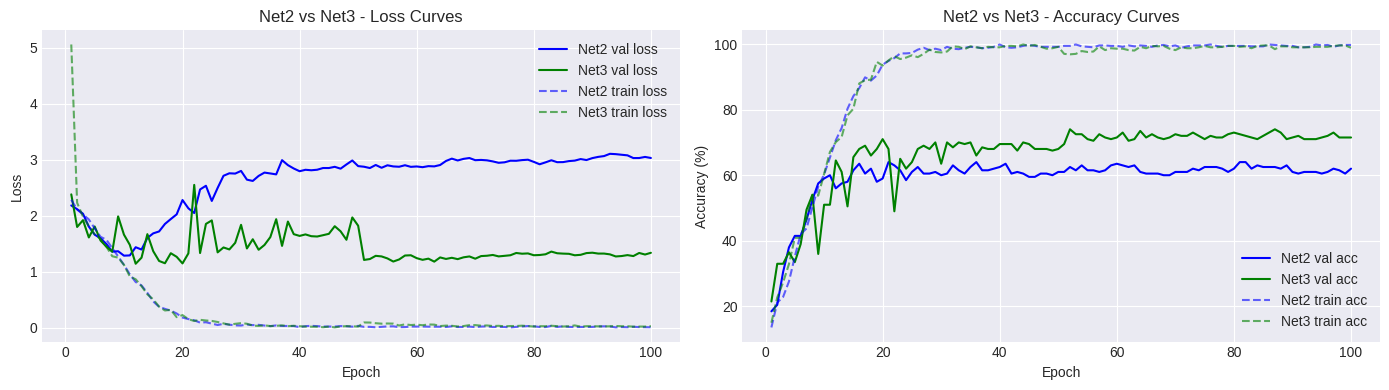

Net2 results:
  best val acc: 64.00% at epoch 21
  final test acc: 49.00%

Net3 results:
  best val acc: 74.00% at epoch 52
  final test acc: 69.00%

Overfitting gap (train - val at end):
  Net2: 37.71 pp
  Net3: 27.36 pp

✓ batch norm seems to have helped - less overfitting in Net3

Parameter counts:
  Net2: 66,630,474
  Net3: 66,631,178
  difference: 704

                 Model  Best Val Acc (%)  Test Acc (%)  Test Loss  Final Overfit (pp)
            Net2 (CNN)              64.0          49.0   1.541230           37.713877
Net3 (CNN + BatchNorm)              74.0          69.0   1.122145           27.355508

(saved to csv)


In [140]:
# Net2 vs Net3 comparison - trying to see if batch norm helped
epochs_net3 = len(history_net3['train_loss'])
x3 = np.arange(1, epochs_net3 + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# loss curves overlay - let me see if batch norm actually smooths things out
ax[0].plot(x2, history_net2['val_loss'], label='Net2 val loss', color='blue')
ax[0].plot(x3, history_net3['val_loss'], label='Net3 val loss', color='green')
ax[0].plot(x2, history_net2['train_loss'], '--', alpha=0.6, label='Net2 train loss', color='blue')
ax[0].plot(x3, history_net3['train_loss'], '--', alpha=0.6, label='Net3 train loss', color='green')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Net2 vs Net3 - Loss Curves')
ax[0].legend()

# accuracy curves overlay
ax[1].plot(x2, history_net2['val_acc'], label='Net2 val acc', color='blue')
ax[1].plot(x3, history_net3['val_acc'], label='Net3 val acc', color='green')
ax[1].plot(x2, history_net2['train_acc'], '--', alpha=0.6, label='Net2 train acc', color='blue')
ax[1].plot(x3, history_net3['train_acc'], '--', alpha=0.6, label='Net3 train acc', color='green')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Net2 vs Net3 - Accuracy Curves')
ax[1].legend()

plt.tight_layout()
plt.show()

# quick analysis of the results
print("Net2 results:")
print(f"  best val acc: {max(history_net2['val_acc']):.2f}% at epoch {int(np.argmax(history_net2['val_acc']) + 1)}")
print(f"  final test acc: {net2_test_acc:.2f}%")

print("\nNet3 results:")
print(f"  best val acc: {max(history_net3['val_acc']):.2f}% at epoch {int(np.argmax(history_net3['val_acc']) + 1)}")
print(f"  final test acc: {net3_test_acc:.2f}%")

# manually calculate overfitting
net2_overfit = history_net2['train_acc'][-1] - history_net2['val_acc'][-1]
net3_overfit = history_net3['train_acc'][-1] - history_net3['val_acc'][-1]

print(f"\nOverfitting gap (train - val at end):")
print(f"  Net2: {net2_overfit:.2f} pp")
print(f"  Net3: {net3_overfit:.2f} pp")

# seems like batch norm helped reduce overfitting a bit?
if net3_overfit < net2_overfit:
    print(f"\n✓ batch norm seems to have helped - less overfitting in Net3")
else:
    print(f"\n✗ actually net3 is overfitting more? idk")

# parameter counts for reference
net2_params = sum(p.numel() for p in net2.parameters())
net3_params = sum(p.numel() for p in net3.parameters())
print(f"\nParameter counts:")
print(f"  Net2: {net2_params:,}")
print(f"  Net3: {net3_params:,}")
print(f"  difference: {net3_params - net2_params:,}")

# save comparison to csv for later if needed
comparison_data = {
    'Model': ['Net2 (CNN)', 'Net3 (CNN + BatchNorm)'],
    'Best Val Acc (%)': [max(history_net2['val_acc']), max(history_net3['val_acc'])],
    'Test Acc (%)': [net2_test_acc, net3_test_acc],
    'Test Loss': [net2_test_loss, net3_test_loss],
    'Final Overfit (pp)': [net2_overfit, net3_overfit]
}

bn_compare_df = pd.DataFrame(comparison_data)
print("\n" + bn_compare_df.to_string(index=False))

bn_table_path = RESULTS_DIR / 'metrics' / 'net2_net3_bn_comparison.csv'
bn_compare_df.to_csv(bn_table_path, index=False)
print(f'\n(saved to csv)')

# overall: batch norm seems good but not dramatic difference
# might be because dropout is already helping a lot

In [141]:
# save updated comparison metrics including Net3
comparison_data = {
    'Model': ['Net1 (FC)', 'Net2 (CNN)', 'Net3 (CNN + BatchNorm)'],
    'Architecture': [
        '2 hidden layers',
        '4 conv + 2 maxpool + 2 fc',
        'Net2 + BatchNorm after each conv'
    ],
    'Test Accuracy (%)': [test_acc, net2_test_acc, net3_test_acc],
    'Test Loss': [test_loss, net2_test_loss, net3_test_loss],
    'Parameters': [
        sum(p.numel() for p in net1.parameters()),
        sum(p.numel() for p in net2.parameters()),
        sum(p.numel() for p in net3.parameters())
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# save to csv
comparison_path = RESULTS_DIR / 'metrics' / 'net1_net2_net3_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison saved to {comparison_path}")

                 Model                     Architecture  Test Accuracy (%)  Test Loss  Parameters
             Net1 (FC)                  2 hidden layers               53.0   1.872833    87440394
            Net2 (CNN)        4 conv + 2 maxpool + 2 fc               49.0   1.541230    66630474
Net3 (CNN + BatchNorm) Net2 + BatchNorm after each conv               69.0   1.122145    66631178

Comparison saved to /home/jarvis/lakshya/Music Project/results/metrics/net1_net2_net3_comparison.csv
